In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader,Subset,Dataset
from torchvision import datasets, transforms
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil
import torch.nn as nn
from torchvision.models import resnet18,ResNet18_Weights
import os
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from sklearn.metrics import roc_curve, roc_auc_score

from PatchDataset import load_dataset,load_augmented_dataset
from pipeline import fit_binary_classifier, evaluate, set_seed,predict_probs

from torch.optim.lr_scheduler import StepLR



In [2]:
PATCH_SIZE = 224
BATCH_SIZE = 32
SEED = 42

PATCHES_ROOT = "patches_dataset/patches_v3_seed42_pad1.6_iouth0.09"
traincsv_path = os.path.join(PATCHES_ROOT, "metadata.csv")
testcsv_path = "patches_dataset/test_patches_v3/test_metadata.csv"

set_seed(SEED)


In [3]:
AUG_ROOT = "patches_dataset/patches_v3_train_aug"
PATH_AUG_METADATA = os.path.join(AUG_ROOT, "metadata.csv")

aug_train_dataset,aug_val_dataset,aug_train_loader,aug_val_loader,aug_test_dataset,aug_test_loader = load_augmented_dataset(
    PATCHES_ROOT,
    AUG_ROOT,
    PATH_AUG_METADATA,
    testcsv_path,
    BATCH_SIZE
)

for xb, yb in aug_train_loader:
    print(xb.shape, yb.shape, min(yb), max(yb))
    break


train_aug/test: 25372 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


In [4]:
# loading the dataset
traindf = pd.read_csv(traincsv_path)
traindf["patch_id"] = traindf["patch_id"].astype(int)
traindf["label"] = traindf["label"].astype(int)
traindf["type"] = traindf["type"].astype(str)

testdf = pd.read_csv(testcsv_path)
testdf["patch_id"] = testdf["patch_id"].astype(int)
testdf["label"] = testdf["label"].astype(int)
testdf["type"] = testdf["type"].astype(str)

train_dataset,val_dataset,train_loader,val_loader,test_dataset,test_loader = load_dataset(traindf,testdf,PATCHES_ROOT,BATCH_SIZE)

for xb,yb in train_loader:
    print(xb.shape,yb.shape,min(yb),max(yb))
    break

train/val: 15858 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Trainable params: 1026


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=2e-5)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
EPOCHS = 20

config = {
    "model": "resnet18_ft",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": 2e-5,
    "early_stopping_patience": 3,
}

In [ ]:
# normal patches
run_dir = "runs/resnet18_ft_seed42"

run_info, best_model = fit_binary_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,          
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_dir=run_dir,
    config=config,
    scheduler=scheduler,
)

Model improved
Epoch 001 | train loss 0.5973 f1 0.8011 acc 0.6800 | val loss 0.5721 f1 0.8095 acc 0.6958 | 
Model improved
Epoch 002 | train loss 0.5458 f1 0.8255 acc 0.7258 | val loss 0.5275 f1 0.8368 acc 0.7468 | 
Model improved
Epoch 003 | train loss 0.5124 f1 0.8474 acc 0.7660 | val loss 0.4954 f1 0.8532 acc 0.7778 | 
Model improved
Epoch 004 | train loss 0.4890 f1 0.8605 acc 0.7894 | val loss 0.4747 f1 0.8651 acc 0.7970 | 
Model improved
Epoch 005 | train loss 0.4719 f1 0.8688 acc 0.8036 | val loss 0.4583 f1 0.8715 acc 0.8093 | 
Model improved
Epoch 006 | train loss 0.4592 f1 0.8704 acc 0.8065 | val loss 0.4529 f1 0.8722 acc 0.8139 | 
Model improved
Epoch 007 | train loss 0.4536 f1 0.8716 acc 0.8096 | val loss 0.4458 f1 0.8738 acc 0.8156 | 
Model improved
Epoch 008 | train loss 0.4467 f1 0.8759 acc 0.8159 | val loss 0.4415 f1 0.8759 acc 0.8172 | 
Model improved
Epoch 009 | train loss 0.4437 f1 0.8764 acc 0.8171 | val loss 0.4338 f1 0.8778 acc 0.8212 | 
Model improved
Epoch 010 | t

In [8]:
# augmented patches
run_dir = "runs/resnet18_ft_seed42_aug"

run_info, best_model = fit_binary_classifier(
    model=model,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,          
    test_loader=aug_test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_dir=run_dir,
    config=config,
    scheduler=scheduler,
)

Model improved
Epoch 001 | train loss 0.6560 f1 0.7121 acc 0.6071 | val loss 0.6068 f1 0.7453 acc 0.6682 | 
Model improved
Epoch 002 | train loss 0.5787 f1 0.7675 acc 0.6978 | val loss 0.5511 f1 0.7894 acc 0.7316 | 
Model improved
Epoch 003 | train loss 0.5398 f1 0.7950 acc 0.7377 | val loss 0.5217 f1 0.8011 acc 0.7519 | 
Model improved
Epoch 004 | train loss 0.5148 f1 0.8122 acc 0.7606 | val loss 0.5005 f1 0.8207 acc 0.7743 | 
Model improved
Epoch 005 | train loss 0.4940 f1 0.8229 acc 0.7753 | val loss 0.4838 f1 0.8283 acc 0.7834 | 
Model improved
Epoch 006 | train loss 0.4832 f1 0.8284 acc 0.7827 | val loss 0.4755 f1 0.8329 acc 0.7880 | 
patience 1/5
Epoch 007 | train loss 0.4779 f1 0.8303 acc 0.7855 | val loss 0.4716 f1 0.8296 acc 0.7881 | 
Model improved
Epoch 008 | train loss 0.4710 f1 0.8314 acc 0.7872 | val loss 0.4652 f1 0.8352 acc 0.7943 | 
patience 1/5
Epoch 009 | train loss 0.4683 f1 0.8339 acc 0.7904 | val loss 0.4609 f1 0.8348 acc 0.7935 | 
Model improved
Epoch 010 | train

In [ ]:
ckpt = torch.load("runs/resnet18_ft_seed42/best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

In [ ]:
# model.load_state_dict(torch.load("runs/resnet18_ft_seed42/best_model.pt", map_location=device))
y_true,y_probs = predict_probs(best_model, test_loader, device)

#y score probas so we make the preds by thresholding at 0.5
y_pred = (y_probs >= 0.5).astype(int)

In [ ]:
y_true, y_probs, y_pred

(array([1, 1, 1, ..., 0, 1, 1], shape=(3965,)),
 array([0.87545884, 0.9524108 , 0.5996345 , ..., 0.94769484, 0.8675487 ,
        0.89848804], shape=(3965,), dtype=float32),
 array([1, 1, 1, ..., 1, 1, 1], shape=(3965,)))

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)  # binary labels must be {0,1}

# AUROC
auc_score = roc_auc_score(y_true, y_probs)
print(f"Validation AUROC: {auc_score:.4f}")


Validation AUROC: 0.8659


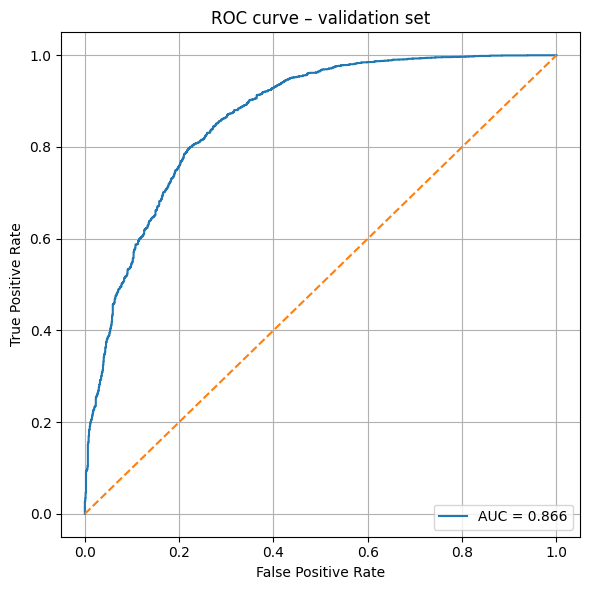

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve – test set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
